# KS at GWL 2.0 on a common 1° grid — with GDP/capita as a variable

Reruns the RAMIP path-independence test (anchor vs `ssp370-126aer`, windows from
`gwl2.0_windows.csv`) with every model regridded to a common **1°** grid, so the pixel-wise
p-maps finally share coordinates and can join `gwl_timeseries.zarr` (the one thing the data
product could not hold per-model). Adds **`gdp`**: the Burke, Hsiang & Miguel (2015) quadratic
GDP-per-capita growth response `g(T) = 0.0127T − 0.0005T²` applied to monthly `tas` in °C —
`g` is non-monotone, so KS on `g(T)` is a genuinely different test from KS on `tas`, and the
monthly application keeps the verified n=120 / block=12 machinery unchanged.

Order of operations, deliberately:
1. load the native-grid window,
2. **transform first** (K→°C, Burke `g`) on the native grid — `g` is nonlinear, so
   transform-then-regrid ≠ regrid-then-transform,
3. **regrid last**, immediately before the KS test: xESMF, `bilinear` for tas/tasmax/tasmin/gdp,
   `conservative` for pr, `periodic=True` (global grids). Arrays are loaded to numpy before
   regridding — lat/lon are never dask-chunked.

Caveat: on coarse models (CanESM5-1 is 64×128) 1° upsampling makes neighbouring pixels
strongly correlated; the land *fraction* is still comparable, pixel counts are not.

In [1]:
import os, warnings
# must be set before xesmf/esmpy import: ESMF lives in the conda side-env
os.environ.setdefault('ESMFMKFILE', '/burg-archive/home/mck2199/summer/.esmf/lib/esmf.mk')
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt

dir_list = get_params()
warnings.filterwarnings('ignore', category=FutureWarning)

RAW     = dir_list['raw'] + 'ramip/'
GWL_DIR = dir_list['aux'] + 'diagnostics/ramip_gwl/'
KS1_DIR = GWL_DIR + 'ks_1deg/'
PRODUCT = dir_list['aux'] + 'gwl_timeseries.zarr'
out_dir = dir_list['aux'] + '../figures/'
os.makedirs(KS1_DIR, exist_ok=True)

GWL, ALPHA = 2.0, 0.05
OTHER  = 'ssp370-126aer'
ANCHOR = {m: 'ssp370' for m in
          ['CanESM5-1', 'CNRM-ESM2-1', 'EC-Earth3-AerChem', 'GISS-E2-1-G', 'MIROC6',
           'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL']}
ANCHOR['CESM2'] = 'ssp370-LE'

VARS    = ['tas', 'pr', 'tasmax', 'tasmin', 'gdp']
SRC_VAR = {'gdp': 'tas'}                       # gdp is derived from tas
METHOD  = {'pr': 'conservative'}               # default: bilinear

B1, B2 = 0.0127, -0.0005                       # Burke, Hsiang & Miguel (2015)


def burke_growth(t_k):
    t = t_k - 273.15
    return B1 * t + B2 * t ** 2


TRANSFORM = {'gdp': burke_growth}

# two comparisons through the identical pipeline: global cleanup and East-Asia-only cleanup
OTHERS = {'glob': 'ssp370-126aer', 'eas': 'ssp370-EAS126aer'}
CACHE_PREFIX = {'glob': '', 'eas': 'eas_'}

win_df = pd.read_csv(f'{GWL_DIR}gwl{GWL}_windows.csv')
_gwl_grp  = xr.open_zarr(PRODUCT, group='gwl')
_gmst_grp = xr.open_zarr(PRODUCT, group='gmst')


def usable_pairs(other_exp):
    """run -> (anchor_end, other_end) per model. The global pair reuses the audited
    gwl2.0_windows.csv; regional arms get their windows from the zarr product's gwl group,
    matched to the same anchor runs by run_id."""
    if other_exp == 'ssp370-126aer':
        return {m: win_df[(win_df.model == m) & win_df.usable] for m in sorted(ANCHOR)}
    out = {}
    for m in sorted(ANCHOR):
        ids = _gmst_grp.run_id.sel(model=m, exp=other_exp).values
        we  = _gwl_grp.window_end.sel(model=m, exp=other_exp, gwl=GWL).values
        end_by_run = {str(r): int(e) for r, e in zip(ids, we) if r and np.isfinite(e)}
        rows = [{'run': row.run, 'anchor_end': row.anchor_end, 'other_end': end_by_run[row.run]}
                for _, row in win_df[(win_df.model == m) & win_df.usable].iterrows()
                if row.run in end_by_run]
        out[m] = pd.DataFrame(rows)
    return out


USABLE = usable_pairs(OTHERS['glob'])
GWL_MODELS = [m for m in sorted(ANCHOR) if len(USABLE[m])]
print('models:', GWL_MODELS)

models: ['CESM2', 'CNRM-ESM2-1', 'CanESM5-1', 'EC-Earth3-AerChem', 'GISS-E2-1-G', 'MIROC6', 'MRI-ESM2-0', 'UKESM1-0-LL']


## Regridding

One `xe.Regridder` per (model, method), reused across variables and runs. The target is a
regular 1° grid with explicit cell bounds (conservative needs them); source bounds are midpoint
bounds built from the native centers, which is exact for regular grids and a sub-cell
approximation for Gaussian ones. `periodic=True` for bilinear; xESMF handles the conservative
wrap through the bounds (it rejects/ignores `periodic` for conservative methods).

In [2]:
GRID_OUT = {'lat': np.arange(-89.5, 90, 1.0),  'lon': np.arange(0.5, 360, 1.0),
            'lat_b': np.arange(-90., 91, 1.0), 'lon_b': np.arange(0., 361, 1.0)}
NLAT, NLON = 180, 360


def _bounds(c):
    b = np.concatenate([[c[0] - (c[1] - c[0]) / 2],
                        (c[:-1] + c[1:]) / 2,
                        [c[-1] + (c[-1] - c[-2]) / 2]])
    return b


_RG = {}


def regridder(mod, da, method):
    if (mod, method) not in _RG:
        lat, lon = da.lat.values, da.lon.values
        src = {'lat': lat, 'lon': lon,
               'lat_b': np.clip(_bounds(lat), -90, 90), 'lon_b': _bounds(lon)}
        _RG[(mod, method)] = xe.Regridder(src, GRID_OUT, method,
                                          periodic=(method == 'bilinear'))
        print(f'  regridder {mod} {method}: {len(lat)}x{len(lon)} -> 1deg')
    return _RG[(mod, method)]


def window_da(fn, var, y_end, win=kt.WIN):
    ds = xr.open_zarr(fn, consolidated=False)
    yr = ds.time.dt.year
    return ds[var].sel(time=(yr > y_end - win) & (yr <= y_end)).load()


def pair_ks_1deg(mod, fn_a, fn_b, var, end_a, end_b):
    """transform on native grid, regrid, then KS. None if a window is short."""
    sides = []
    for fn, end in [(fn_a, end_a), (fn_b, end_b)]:
        da = window_da(fn, SRC_VAR.get(var, var), int(end))
        if da.sizes['time'] != 12 * kt.WIN:
            return None
        if var in TRANSFORM:
            da = TRANSFORM[var](da)                      # 1. transform first (native grid)
        v = regridder(mod, da, METHOD.get(var, 'bilinear'))(da)   # 2. regrid last
        sides.append(v.transpose('lat', 'lon', 'time').values.reshape(-1, v.sizes['time']))
    A, B = sides                                          # 3. KS on the common grid
    return (kt.block_perm_map(A, B).reshape(NLAT, NLON),
            kt.ks_fast(A, B).reshape(NLAT, NLON))


# self-check: iid noise through the full path must not reject
_r = np.random.default_rng(0)
_noise = xr.DataArray(_r.standard_normal((240, 4, 8)).astype('float32'),
                      dims=('time', 'lat', 'lon'),
                      coords={'lat': np.linspace(-60, 60, 4), 'lon': np.arange(0, 360, 45.)})
_rg = xe.Regridder({'lat': _noise.lat.values, 'lon': _noise.lon.values},
                   {'lat': np.array([-30., 30.]), 'lon': np.array([90., 270.])},
                   'bilinear', periodic=True)
_a, _b = [_rg(_noise.isel(time=sl)).transpose('lat', 'lon', 'time').values.reshape(4, 120)
          for sl in (slice(0, 120), slice(120, 240))]
_p = kt.block_perm_map(_a, _b)
print('iid regridded check, block-perm p:', np.round(_p, 3), ' (should be well above 0.05)')
assert (_p > ALPHA).all()

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/xesmf/frontend.py:788: UserWarning: Using dimensions ('lat', 'lon') from data variable None as the horizontal dimensions for the regridding.
  warnings.warn(


/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/xesmf/frontend.py:788: UserWarning: Using dimensions ('lat', 'lon') from data variable None as the horizontal dimensions for the regridding.
  warnings.warn(


iid regridded check, block-perm p: [0.952 0.059 0.984 0.29 ]  (should be well above 0.05)


## KS maps, all variables on 1°

Cache: `ramip_gwl/ks_1deg/{var}_{model}.nc`, one file per (variable, model), dims
`(run, lat, lon)` on the common grid — same schema as the native caches.

In [3]:
results = {}
for cmp_key, other_exp in OTHERS.items():
    PAIRS = usable_pairs(other_exp)
    pre = CACHE_PREFIX[cmp_key]
    for var in VARS:
        for mod in GWL_MODELS:
            cache_fn = f'{KS1_DIR}{pre}{var}_{mod}.nc'
            if os.path.exists(cache_fn):
                results[(cmp_key, var, mod)] = xr.open_dataset(cache_fn).load()
                print(f'{cmp_key} {var} {mod}: loaded cache '
                      f'({results[(cmp_key, var, mod)].sizes["run"]} runs)')
                continue
            afns = kt.member_files(RAW, mod, ANCHOR[mod], SRC_VAR.get(var, var))
            bfns = kt.member_files(RAW, mod, other_exp, SRC_VAR.get(var, var))
            bp, asy, runs_used = [], [], []
            for _, row in PAIRS[mod].iterrows():
                if row.run not in afns or row.run not in bfns:
                    print(f'  {cmp_key} {var} {mod} {row.run}: no file, skipped')
                    continue
                out = pair_ks_1deg(mod, afns[row.run], bfns[row.run], var,
                                   row.anchor_end, row.other_end)
                if out is None:
                    print(f'  {cmp_key} {var} {mod} {row.run}: short window, skipped')
                    continue
                bp.append(out[0]); asy.append(out[1]); runs_used.append(row.run)
                print(f'  {cmp_key} {var} {mod} {row.run} done', flush=True)
            if not runs_used:
                print(f'{cmp_key} {var} {mod}: nothing usable')
                continue
            dims = ('run', 'lat', 'lon')
            ds = xr.Dataset({'p_blockperm': (dims, np.stack(bp).astype('float32')),
                             'p_asymptotic': (dims, np.stack(asy).astype('float32'))},
                            coords={'run': runs_used,
                                    'lat': GRID_OUT['lat'], 'lon': GRID_OUT['lon']})
            ds.attrs.update(gwl=GWL, variable=var, source_variable=SRC_VAR.get(var, var),
                            other_exp=other_exp,
                            regrid=f"xESMF {xe.__version__} {METHOD.get(var, 'bilinear')}, 1deg, "
                                   'periodic, transform-before-regrid')
            ds.to_netcdf(cache_fn)
            results[(cmp_key, var, mod)] = ds
            print(f'{cmp_key} {var} {mod}: {len(runs_used)} runs -> {cache_fn}')

glob tas CESM2: loaded cache (10 runs)
glob tas CNRM-ESM2-1: loaded cache (6 runs)
glob tas CanESM5-1: loaded cache (10 runs)
glob tas EC-Earth3-AerChem: loaded cache (6 runs)
glob tas GISS-E2-1-G: loaded cache (10 runs)
glob tas MIROC6: loaded cache (10 runs)
glob tas MRI-ESM2-0: loaded cache (10 runs)
glob tas UKESM1-0-LL: loaded cache (10 runs)
glob pr CESM2: loaded cache (10 runs)
glob pr CNRM-ESM2-1: loaded cache (6 runs)
glob pr CanESM5-1: loaded cache (10 runs)


glob pr EC-Earth3-AerChem: loaded cache (6 runs)
glob pr GISS-E2-1-G: loaded cache (10 runs)
glob pr MIROC6: loaded cache (10 runs)
glob pr MRI-ESM2-0: loaded cache (10 runs)
glob pr UKESM1-0-LL: loaded cache (10 runs)
glob tasmax CESM2: loaded cache (10 runs)


glob tasmax CNRM-ESM2-1: loaded cache (6 runs)
glob tasmax CanESM5-1: loaded cache (10 runs)
glob tasmax EC-Earth3-AerChem: loaded cache (6 runs)
glob tasmax GISS-E2-1-G: loaded cache (10 runs)
glob tasmax MIROC6: loaded cache (10 runs)
glob tasmax MRI-ESM2-0: loaded cache (10 runs)
glob tasmax UKESM1-0-LL: loaded cache (10 runs)
glob tasmin CESM2: loaded cache (9 runs)
glob tasmin CNRM-ESM2-1: loaded cache (6 runs)
glob tasmin CanESM5-1: loaded cache (10 runs)
glob tasmin EC-Earth3-AerChem: loaded cache (6 runs)
glob tasmin GISS-E2-1-G: loaded cache (10 runs)


glob tasmin MIROC6: loaded cache (10 runs)
glob tasmin MRI-ESM2-0: loaded cache (10 runs)
glob tasmin UKESM1-0-LL: loaded cache (10 runs)
glob gdp CESM2: loaded cache (10 runs)
glob gdp CNRM-ESM2-1: loaded cache (6 runs)
glob gdp CanESM5-1: loaded cache (10 runs)
glob gdp EC-Earth3-AerChem: loaded cache (6 runs)


glob gdp GISS-E2-1-G: loaded cache (10 runs)
glob gdp MIROC6: loaded cache (10 runs)
glob gdp MRI-ESM2-0: loaded cache (10 runs)
glob gdp UKESM1-0-LL: loaded cache (10 runs)


...

  eas gdp UKESM1-0-LL r8i1p1f2 done


/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/xesmf/frontend.py:788: UserWarning: Using dimensions ('lat', 'lon') from data variable tas as the horizontal dimensions for the regridding.
  warnings.warn(


/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/xesmf/frontend.py:788: UserWarning: Using dimensions ('lat', 'lon') from data variable tas as the horizontal dimensions for the regridding.
  warnings.warn(


  eas gdp UKESM1-0-LL r9i1p1f2 done


eas gdp UKESM1-0-LL: 10 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/ks_1deg/eas_gdp_UKESM1-0-LL.nc


## Land fractions: 1° vs native

`kt.land_fraction` convention (all land incl. Antarctica), same as every earlier result table,
so the native columns are directly comparable. Floor caveat unchanged: the quoted 0.057 was
measured excluding Antarctica.

In [4]:
native = {}
for var in VARS:
    d = 'ks' if var == 'tas' else f'ks_{var}'
    for mod in GWL_MODELS:
        fn = f'{GWL_DIR}{d}/{mod}.nc'
        if var != 'gdp' and os.path.exists(fn):
            native[(var, mod)] = xr.open_dataset(fn)

frac = {}
for cmp_key in OTHERS:
    rows = []
    for mod in GWL_MODELS:
        row = {'model': mod}
        for var in VARS:
            if (cmp_key, var, mod) in results:
                row[var] = kt.land_fraction(results[(cmp_key, var, mod)], 'run', ALPHA)
            if cmp_key == 'glob' and (var, mod) in native:
                row[f'{var}_native'] = kt.land_fraction(native[(var, mod)], 'run', ALPHA)
        rows.append(row)
    frac[cmp_key] = pd.DataFrame(rows).set_index('model')
frac_df = frac['glob']
frac_df.to_csv(f'{GWL_DIR}land_fractions_1deg.csv')
frac['eas'].to_csv(f'{GWL_DIR}land_fractions_1deg_eas.csv')
for cmp_key, other_exp in OTHERS.items():
    print(f'\n{other_exp}:')
    print(frac[cmp_key][VARS].round(3).to_string())
    print(f'means: {frac[cmp_key][VARS].mean().round(3).to_dict()}')
    leads = [float((usable_pairs(other_exp)[m].anchor_end
                    - usable_pairs(other_exp)[m].other_end).mean()) for m in GWL_MODELS]
    print(f'GMST lead at GWL{GWL} (anchor_end - other_end): mean {np.nanmean(leads):.1f} yr '
          '-> how much the cleanup itself moves global warming')

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



ssp370-126aer:
                     tas     pr  tasmax  tasmin    gdp
model                                                 
CESM2              0.070  0.045   0.048   0.068  0.062
CNRM-ESM2-1        0.048  0.045   0.049   0.050  0.049
CanESM5-1          0.040  0.049   0.041   0.033  0.041
EC-Earth3-AerChem  0.071  0.059   0.070   0.053  0.065
GISS-E2-1-G        0.045  0.047   0.046   0.044  0.045
MIROC6             0.065  0.050   0.074   0.053  0.057
MRI-ESM2-0         0.055  0.056   0.059   0.050  0.050
UKESM1-0-LL        0.065  0.044   0.061   0.060  0.063
means: {'tas': 0.057, 'pr': 0.05, 'tasmax': 0.056, 'tasmin': 0.051, 'gdp': 0.054}
GMST lead at GWL2.0 (anchor_end - other_end): mean 6.1 yr -> how much the cleanup itself moves global warming

ssp370-EAS126aer:
                     tas     pr  tasmax  tasmin    gdp
model                                                 
CESM2              0.047  0.054   0.050   0.043  0.047
CNRM-ESM2-1        0.039  0.045   0.037   0.039  0.037
Can

GMST lead at GWL2.0 (anchor_end - other_end): mean 2.0 yr -> how much the cleanup itself moves global warming


## Into the data product

New group `ks` in `gwl_timeseries.zarr`: `p_blockperm(var, model, pair, lat, lon)` (float32) on
the shared 1° grid, `run_id(model, pair)` carrying the real member identifier, NaN where a
(model, pair) does not exist — the same sparsity convention as the rest of the store. The
asymptotic p stays in the netCDF caches only (comparison diagnostic, not a result).

In [5]:
import shutil

per_cmp = []
for cmp_key, other_exp in OTHERS.items():
    per_var = []
    for var in VARS:
        per_mod = []
        for mod in GWL_MODELS:
            if (cmp_key, var, mod) not in results:
                continue
            d = results[(cmp_key, var, mod)].p_blockperm
            d = d.rename({'run': 'pair'}).assign_coords(pair=np.arange(d.sizes['run']))
            per_mod.append(d.assign_coords(model=mod))
        per_var.append(xr.concat(per_mod, dim='model', join='outer').assign_coords(var=var))
    per_cmp.append(xr.concat(per_var, dim='var', join='outer')
                   .assign_coords(comparison=other_exp.replace('ssp370-', '')))
ks_da = xr.concat(per_cmp, dim='comparison', join='outer')

rid = xr.concat(
    [xr.DataArray([str(r) for r in results[('glob', 'tas', m)].run.values], dims='pair')
       .assign_coords(pair=np.arange(results[('glob', 'tas', m)].sizes['run']), model=m)
     for m in GWL_MODELS if ('glob', 'tas', m) in results],
    dim='model', join='outer').fillna('').astype('U20')

ks_ds = xr.Dataset({'p_blockperm': ks_da.astype('float32'), 'run_id': rid})
ks_ds.p_blockperm.attrs = {
    'long_name': 'block-permutation KS p-value, anchor vs cleanup arm at matched GWL 2.0',
    'comparison_note': '126aer = global cleanup, EAS126aer = East-Asia-only cleanup',
    'grid': '1deg regular, regridded with xESMF (bilinear; conservative for pr), periodic',
    'order_of_operations': 'transform on native grid first, regrid last, then KS',
    'gdp_definition': 'Burke-Hsiang-Miguel (2015) g(T)=0.0127T-0.0005T^2 on monthly tas degC',
    'block_months': kt.BLOCK, 'ndraws': kt.NDRAWS, 'window_years': kt.WIN, 'alpha': ALPHA,
    'false_positive_floor': '0.057 land fraction (same-forcing CanESM5-1 pairs, excl. Antarctica)',
    'anchor': 'ssp370 (CESM2: ssp370-LE)'}
ks_ds.run_id.attrs = {'long_name': 'CMIP6 member identifier for this pair index (global arm; '
                                   'regional arms pair the same runs where present)',
                      'note': 'empty string where the (model, pair) does not exist'}
ks_ds.attrs = {'group': 'ks', 'created_by': 'path_independence/pipeline/ks_gwl_1deg.ipynb',
               'gwl': GWL}

shutil.rmtree(PRODUCT + '/ks', ignore_errors=True)
for v in list(ks_ds.variables):
    ks_ds[v].encoding = {}
ks_ds.chunk({'lat': NLAT, 'lon': NLON}).to_zarr(PRODUCT, group='ks', mode='a')
print('wrote group ks:', dict(ks_ds.sizes))

chk = xr.open_zarr(PRODUCT, group='ks')
m0 = GWL_MODELS[0]
src0 = results[('eas', 'gdp', m0)].p_blockperm.isel(run=0)
got0 = chk.p_blockperm.sel(comparison='EAS126aer', var='gdp', model=m0).isel(pair=0)
assert float(np.abs(src0.values - got0.values).max()) == 0.0
print('verify: EAS126aer gdp', m0, 'pair 0 round-trips exactly')

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


wrote group ks: {'lat': 180, 'lon': 360, 'pair': 10, 'model': 8, 'var': 5, 'comparison': 2}


verify: EAS126aer gdp CESM2 pair 0 round-trips exactly


## Figures

Left: land fractions per variable (gdp alongside the physical variables), floor dashed. Right
block: multi-model mean rejection frequency per variable — the map the native grids could not
draw, and the point of the regridding.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_landfrac_1deg_gwl2.0.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_fracmaps_1deg_gwl2.0.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_landfrac_1deg_gwl2.0_eas.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_fracmaps_1deg_gwl2.0_eas.png


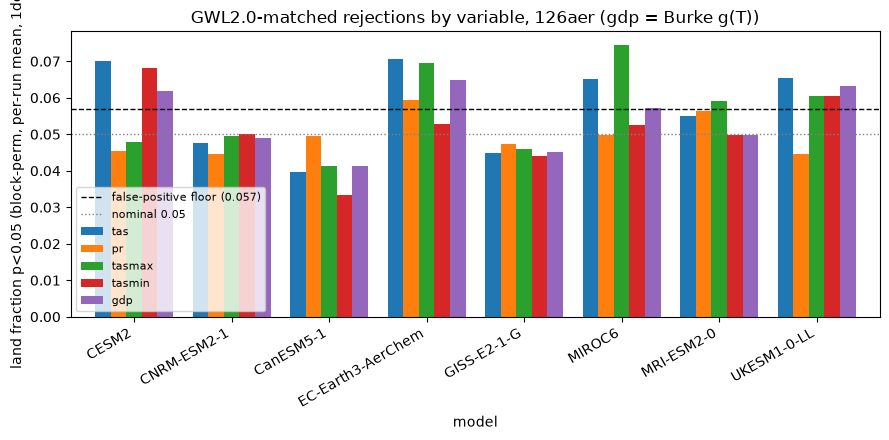

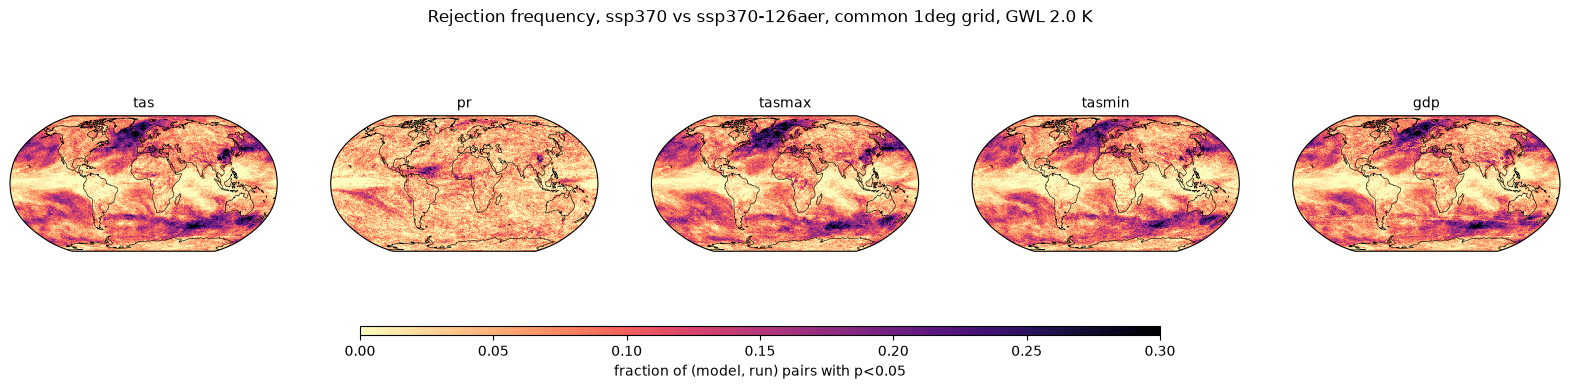

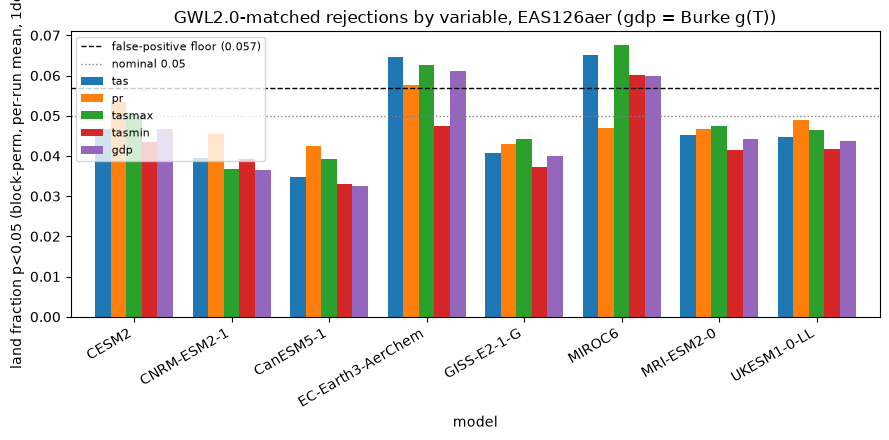

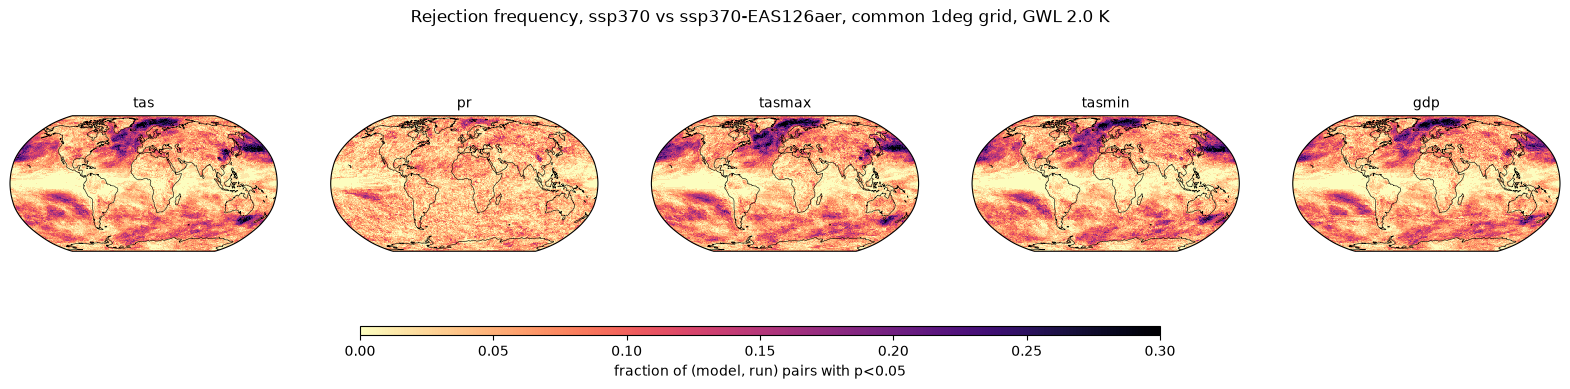

In [6]:
chk = xr.open_zarr(PRODUCT, group='ks')
for cmp_key, other_exp in OTHERS.items():
    tag = other_exp.replace('ssp370-', '')
    suf = '' if cmp_key == 'glob' else f'_{cmp_key}'

    fig, ax = plt.subplots(figsize=(9, 4.5))
    frac[cmp_key][VARS].plot.bar(ax=ax, width=0.8)
    ax.axhline(0.057, color='k', ls='--', lw=1, label='false-positive floor (0.057)')
    ax.axhline(ALPHA, color='grey', ls=':', lw=1, label=f'nominal {ALPHA}')
    ax.set_ylabel(f'land fraction p<{ALPHA} (block-perm, per-run mean, 1deg)')
    ax.set_title(f'GWL{GWL}-matched rejections by variable, {tag} (gdp = Burke g(T))')
    ax.legend(fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(out_dir + f'ks_blockperm_landfrac_1deg_gwl{GWL}{suf}.png',
                dpi=150, bbox_inches='tight')
    print('saved', out_dir + f'ks_blockperm_landfrac_1deg_gwl{GWL}{suf}.png')

    rej = (chk.p_blockperm.sel(comparison=tag) < ALPHA)\
        .where(chk.p_blockperm.sel(comparison=tag).notnull()).mean(('model', 'pair'))
    fig, axs = plt.subplots(1, len(VARS), figsize=(4 * len(VARS), 3.2),
                            subplot_kw={'projection': ccrs.Robinson()})
    for ax, var in zip(np.atleast_1d(axs), VARS):
        fld = rej.sel(var=var)
        im = ax.pcolormesh(fld.lon, fld.lat, fld, cmap='magma_r', vmin=0, vmax=0.3,
                           transform=ccrs.PlateCarree())
        ax.coastlines(lw=0.4)
        ax.set_title(var, fontsize=10)
    cax = fig.add_axes([0.3, 0.02, 0.4, 0.03])
    fig.colorbar(im, cax=cax, orientation='horizontal',
                 label=f'fraction of (model, run) pairs with p<{ALPHA}')
    fig.suptitle(f'Rejection frequency, ssp370 vs {other_exp}, common 1deg grid, GWL {GWL} K',
                 y=1.04)
    fig.savefig(out_dir + f'ks_blockperm_fracmaps_1deg_gwl{GWL}{suf}.png',
                dpi=150, bbox_inches='tight')
    print('saved', out_dir + f'ks_blockperm_fracmaps_1deg_gwl{GWL}{suf}.png')

## Wilks (2016) FDR field significance

Counting raw p<0.05 pixels is exactly the "stippling" Wilks (2016) warns overstates results —
under a true null ~5% of pixels reject by construction, which is why everything above needed a
measured floor to interpret. The FDR test (`kt.sig_fdr`, α_FDR = 0.2 per Wilks' guidance for
spatially correlated fields) controls the false discovery rate over the whole field instead: a
pixel is significant only if its p-value beats the rank-scaled threshold
p_FDR = max{p(i) : p(i) < (i/N)·α_FDR}. Under path-independence the FDR-significant fraction
should collapse to ~0 with no floor needed; a real distributional difference should survive.

Applied land-only (ocean NaN'd, so N = land pixels — the field interrogated is land, matching
every land-fraction number above): the aerosol family on the 1° maps for all five variables, and
the native-grid scenario/overshoot `tas` caches for the family contrast.

FDR-significant land fraction (Wilks 2016, alpha_FDR=0.2), ssp370-126aer, 1deg:
                      tas   pr  tasmax  tasmin     gdp
model                                                 
CESM2              0.0000  0.0     0.0  0.0000  0.0000
CNRM-ESM2-1        0.0000  0.0     0.0  0.0000  0.0000
CanESM5-1          0.0000  0.0     0.0  0.0000  0.0000
EC-Earth3-AerChem  0.0000  0.0     0.0  0.0000  0.0000
GISS-E2-1-G        0.0000  0.0     0.0  0.0000  0.0000
MIROC6             0.0000  0.0     0.0  0.0000  0.0000
MRI-ESM2-0         0.0000  0.0     0.0  0.0000  0.0000
UKESM1-0-LL        0.0038  0.0     0.0  0.0018  0.0034
means: {'tas': 0.0005, 'pr': 0.0, 'tasmax': 0.0, 'tasmin': 0.0002, 'gdp': 0.0004}



FDR-significant land fraction (Wilks 2016, alpha_FDR=0.2), ssp370-EAS126aer, 1deg:
                      tas      pr  tasmax  tasmin     gdp
model                                                    
CESM2              0.0000  0.0000  0.0000  0.0000  0.0000
CNRM-ESM2-1        0.0000  0.0000  0.0000  0.0000  0.0000
CanESM5-1          0.0000  0.0000  0.0000  0.0000  0.0000
EC-Earth3-AerChem  0.0000  0.0057  0.0000  0.0000  0.0000
GISS-E2-1-G        0.0000  0.0000  0.0000  0.0000  0.0000
MIROC6             0.0000  0.0000  0.0000  0.0000  0.0000
MRI-ESM2-0         0.0000  0.0029  0.0000  0.0000  0.0000
UKESM1-0-LL        0.0072  0.0000  0.0071  0.0062  0.0071
means: {'tas': 0.0009, 'pr': 0.0011, 'tasmax': 0.0009, 'tasmin': 0.0008, 'gdp': 0.0009}



scenario:
                                          raw     fdr
case                                                 
scen_CESM2_ssp126_vs_ssp245_tas        0.0659  0.0000
scen_CESM2_ssp126_vs_ssp585_tas        0.0692  0.0000
scen_CESM2_ssp245_vs_ssp585_tas        0.0629  0.0000
scen_CNRM-ESM2-1_ssp126_vs_ssp245_tas  0.0774  0.0000
scen_CNRM-ESM2-1_ssp126_vs_ssp585_tas  0.0673  0.0000
scen_CNRM-ESM2-1_ssp245_vs_ssp585_tas  0.0646  0.0000
scen_CanESM5_ssp126_vs_ssp245_tas      0.0468  0.0038
scen_CanESM5_ssp126_vs_ssp585_tas      0.0464  0.0000
scen_CanESM5_ssp245_vs_ssp585_tas      0.0328  0.0000
scen_GISS-E2-1-G_ssp126_vs_ssp245_tas  0.0464  0.0000
scen_GISS-E2-1-G_ssp126_vs_ssp585_tas  0.0549  0.0035
scen_GISS-E2-1-G_ssp245_vs_ssp585_tas  0.0519  0.0088
scen_MIROC6_ssp245_vs_ssp585_tas       0.0398  0.0000
scen_MRI-ESM2-0_ssp245_vs_ssp585_tas   0.0437  0.0000
scen_UKESM1-0-LL_ssp126_vs_ssp245_tas  0.0393  0.0000
scen_UKESM1-0-LL_ssp126_vs_ssp585_tas  0.0511  0.0000
scen_UKESM1-0-LL_s

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_wilks_fdr_families.png


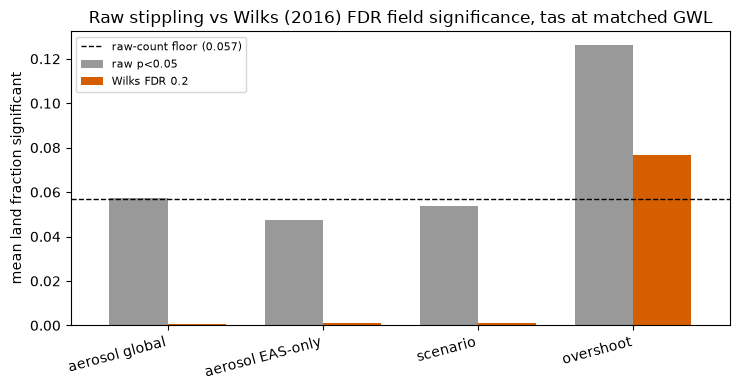

In [7]:
FDR = 0.2

fdr = {}
for cmp_key, other_exp in OTHERS.items():
    rows = []
    for mod in GWL_MODELS:
        row = {'model': mod}
        for var in VARS:
            if (cmp_key, var, mod) in results:
                row[var] = kt.fdr_land_fraction(results[(cmp_key, var, mod)], 'run', FDR)
        rows.append(row)
    fdr[cmp_key] = pd.DataFrame(rows).set_index('model')
    print(f'FDR-significant land fraction (Wilks 2016, alpha_FDR={FDR}), {other_exp}, 1deg:')
    print(fdr[cmp_key].round(4).to_string())
    print(f'means: {fdr[cmp_key][VARS].mean().round(4).to_dict()}\n')
fdr_df = fdr['glob']
fdr_df.to_csv(f'{GWL_DIR}land_fractions_1deg_fdr.csv')
fdr['eas'].to_csv(f'{GWL_DIR}land_fractions_1deg_fdr_eas.csv')

# family contrast on the native-grid scenario / overshoot tas caches
import glob
SCEN_KS = dir_list['aux'] + 'diagnostics/ks_scenarios/'
fam = {}
for name, pat in [('scenario', 'scen_*_tas.nc'), ('overshoot', 'over_*_tas.nc')]:
    recs = []
    for fn in sorted(glob.glob(SCEN_KS + pat)):
        d = xr.open_dataset(fn)
        recs.append({'case': os.path.basename(fn)[:-3],
                     'raw': kt.land_fraction(d, 'pair', ALPHA),
                     'fdr': kt.fdr_land_fraction(d, 'pair', FDR)})
    fam[name] = pd.DataFrame(recs).set_index('case')
    print(f'{name}:')
    print(fam[name].round(4).to_string())

comp = pd.DataFrame({
    'raw p<0.05': [frac['glob']['tas'].mean(), frac['eas']['tas'].mean(),
                   fam['scenario']['raw'].mean(), fam['overshoot']['raw'].mean()],
    f'Wilks FDR {FDR}': [fdr['glob']['tas'].mean(), fdr['eas']['tas'].mean(),
                         fam['scenario']['fdr'].mean(), fam['overshoot']['fdr'].mean()],
}, index=['aerosol global', 'aerosol EAS-only', 'scenario', 'overshoot'])
comp.to_csv(f'{GWL_DIR}wilks_fdr_families.csv')
print('\nfamily summary (tas, mean land fraction):')
print(comp.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4))
comp.plot.bar(ax=ax, width=0.75, color=['#999999', '#D55E00'])
ax.axhline(0.057, color='k', ls='--', lw=1, label='raw-count floor (0.057)')
ax.set_ylabel('mean land fraction significant')
ax.set_title('Raw stippling vs Wilks (2016) FDR field significance, tas at matched GWL')
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
fig.tight_layout()
fig.savefig(out_dir + 'ks_wilks_fdr_families.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_wilks_fdr_families.png')